In [ ]:
import pandas as pd


df = pd.read_csv("../data/tmdb_movies.csv")

print("First 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nDescriptive statistics (includes mean and std for numeric columns):")
print(df.describe())

numeric_cols = df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    print(f"{col}: Mean = {mean_val}, Std = {std_val}")

First 5 rows:
   tmdb_id             title release_date  runtime    budget   revenue  \
0   511498  The Dirt on Soap   2000-01-01        1      2883      2883   
1    19214   Passion of Mind   2000-01-07      105  12000000    769272   
2    17908       My Dog Skip   2000-01-12       95   6000000  35547761   
3    10471       Next Friday   2000-01-12       98  11000000  59827328   
4    10384         Supernova   2000-01-14       91  90000000  14828081   

                                                cast  \
0                                     ['Rick Jones']   
1  ['Demi Moore', 'William Fichtner', 'Eloise Eon...   
2  ['Frankie Muniz', 'Diane Lane', 'Kevin Bacon',...   
3  ['Ice Cube', 'Mike Epps', 'Justin Pierce', 'Jo...   
4  ['James Spader', 'Angela Bassett', 'Robert For...   

                                                crew countries    status  \
0  ['Sylvain Proteau', 'Denis Larochelle', 'Sylva...    ['CA']  Released   
1  ['Alain Berliner', 'David Field', 'Ronald Bass...

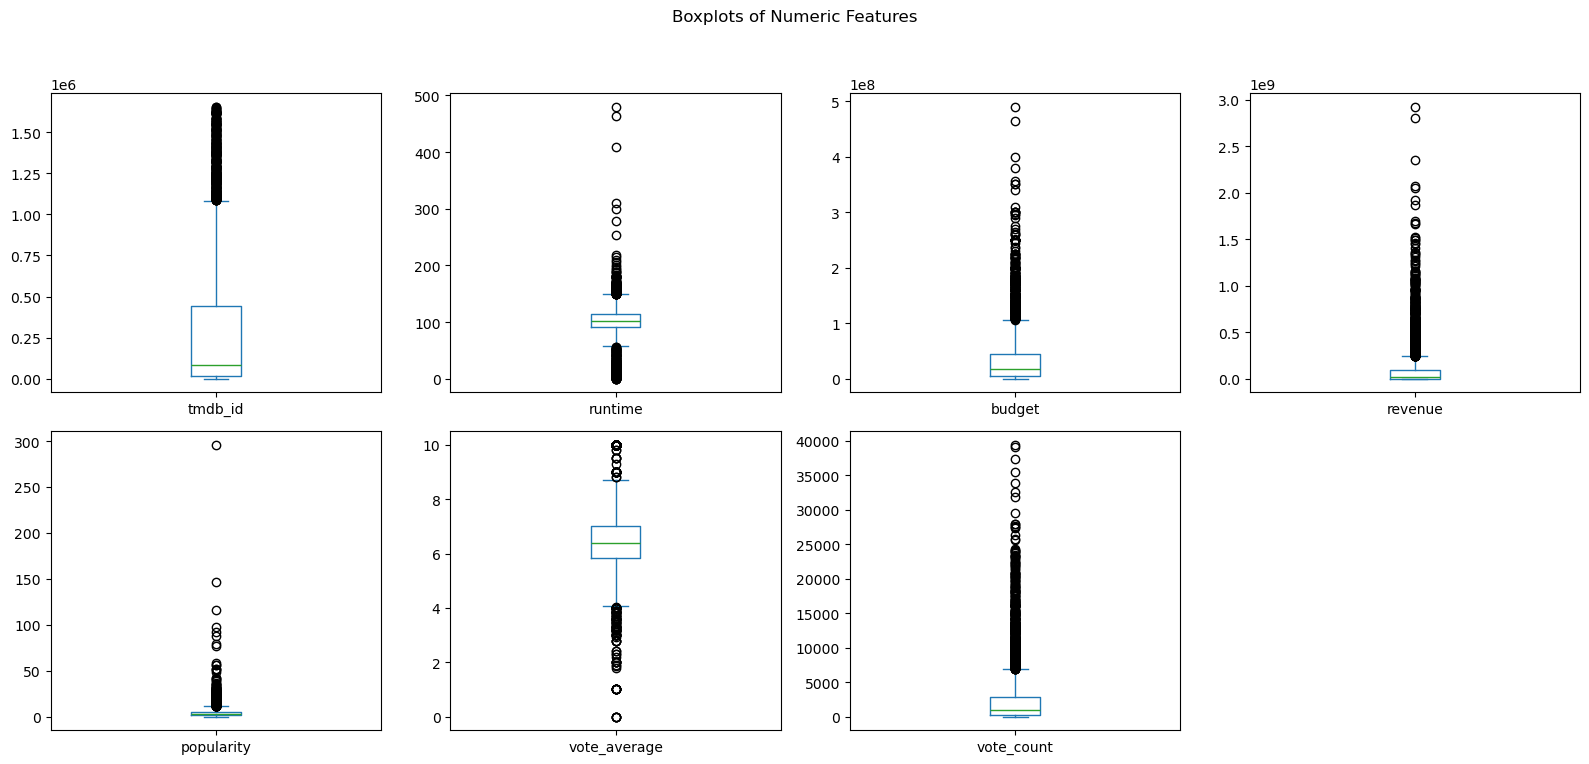

In [10]:
df[numeric_cols].plot.box(
    subplots=True, layout=(2, 4), figsize=(16, 8), sharex=False, sharey=False
)
plt.suptitle("Boxplots of Numeric Features")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

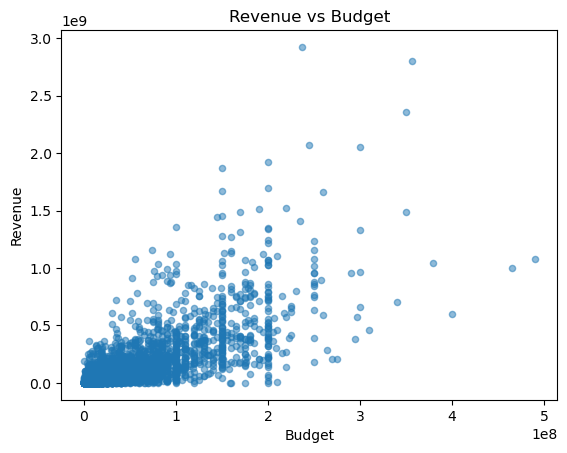

In [7]:
import matplotlib.pyplot as plt

df.plot.scatter(x="budget", y="revenue", alpha=0.5)
plt.title("Revenue vs Budget")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

              title    budget   revenue       roi
0  The Dirt on Soap      2883      2883  0.000000
1   Passion of Mind  12000000    769272 -0.935894
2       My Dog Skip   6000000  35547761  4.924627
3       Next Friday  11000000  59827328  4.438848
4         Supernova  90000000  14828081 -0.835244


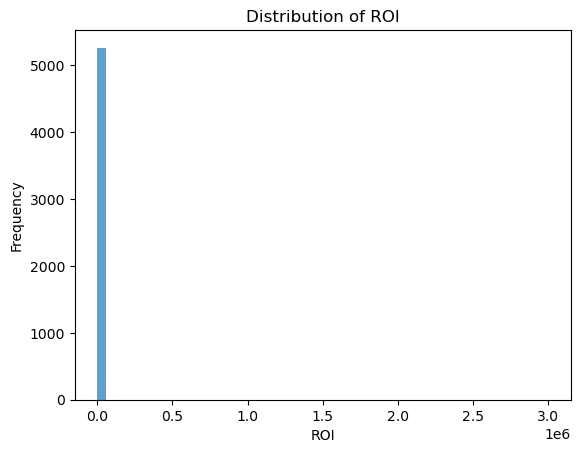

In [9]:
df["roi"] = ((df["revenue"] - df["budget"]) / df["budget"]).where(df["budget"] != 0)

print(df[["title", "budget", "revenue", "roi"]].head())

ax = df["roi"].plot.hist(bins=50, alpha=0.7)
plt.title("Distribution of ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")
plt.show()